# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for Fine Tuning!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [1]:
# imports

import os
import re
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from items import Item
from testing import Tester

In [5]:
openai = OpenAI()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [8]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 200 examples (and 1 epoch)

#fine_tune_train = train[:200]
#fine_tune_validation = train[200:250]
fine_tune_train = train[:500]
fine_tune_validation = train[500:550]

In [9]:
train[0].price

67.28

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
# Extract prices
prices = np.array([item.price for item in train])

# Create histogram bins
n_total_samples = 150
n_train_samples = 100
n_val_samples = n_total_samples - n_train_samples
n_bins = 50
counts, bin_edges = np.histogram(prices, bins=n_bins)

# Assign each item to a bin
bin_indices = np.digitize(prices, bins=bin_edges, right=True)

# Proportional sampling
sampled = []
for bin_num in range(1, n_bins + 1):
    items_in_bin = [item for i, item in enumerate(train) if bin_indices[i] == bin_num]
    if not items_in_bin:
        continue
    bin_fraction = len(items_in_bin) / len(train)
    n_samples = max(1, int(n_total_samples * bin_fraction))
    sampled.extend(random.sample(items_in_bin, min(n_samples, len(items_in_bin))))

# Trim to exactly if needed
if len(sampled) > n_total_samples:
    sampled = random.sample(sampled, n_total_samples)

# Shuffle to ensure randomness
random.shuffle(sampled)

# Split into training and validation sets
fine_tune_train = sampled[n_val_samples:]
fine_tune_validation = sampled[:n_val_samples]

In [11]:
fine_tune_train[0].price

4.99

In [12]:
# Create bins across full price range
#min_price, max_price = min(prices), max(prices)
#bin_edges = np.linspace(min_price, max_price, 551)

#sampled = []
#for i in range(n_total_samples):
#    bin_items = [item for item in train if bin_edges[i] <= item.price < bin_edges[i+1]]
#    if bin_items:
#        sampled.append(random.choice(bin_items))

# Shuffle to ensure randomness
#random.shuffle(sampled)

# Split into training and validation sets
#fine_tune_train = sampled[n_val_samples:]
#fine_tune_validation = sampled[:n_val_samples]

# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [13]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [14]:
messages_for(train[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nCURT 56422 Vehicle-Side Custom 4-Pin Trailer Wiring Harness, Fits Select Volkswagen Tiguan\nIf your vehicle is not equipped with wiring for towing a trailer, CURT custom wiring is the ideal solution. A custom wiring harness -- also called a T-connector -- is a simple, plug-and-play electrical device that plugs into your automotive electric system and provides a standard, universal trailer wiring connection. This is done using two or more vehicle-specific, OEM-compatible connectors to plug into the taillight assembly, eliminating the need for cutting, splicing and soldering during installation. Custom wiring harnesses are made vehicle-specific, and while they are not available for all vehicles, they do offer one of the fastest, easiest and most secure ways to wire a vehicle for towing. This particular'},
 {'role': 'assis

In [15]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [16]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nCURT 56422 Vehicle-Side Custom 4-Pin Trailer Wiring Harness, Fits Select Volkswagen Tiguan\nIf your vehicle is not equipped with wiring for towing a trailer, CURT custom wiring is the ideal solution. A custom wiring harness -- also called a T-connector -- is a simple, plug-and-play electrical device that plugs into your automotive electric system and provides a standard, universal trailer wiring connection. This is done using two or more vehicle-specific, OEM-compatible connectors to plug into the taillight assembly, eliminating the need for cutting, splicing and soldering during installation. Custom wiring harnesses are made vehicle-specific, and while they are not available for all vehicles, they do offer one of the fastest, easiest and most secure ways to wire a vehicle for towing. This particular"}, {"role":

In [17]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [18]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [19]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [20]:
# Uploads the file to OpenAI’s servers for the purpose of fine-tuning a model
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [21]:
train_file

FileObject(id='file-7xboXMCNWfuRTV7hNxrAPd', bytes=91897, created_at=1751396285, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [22]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [23]:
validation_file

FileObject(id='file-BSZYKCw8X9iMm16NMrBtPe', bytes=47123, created_at=1751396286, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [24]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [25]:
train_file.id

'file-7xboXMCNWfuRTV7hNxrAPd'

In [26]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki', created_at=1751396288, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-TgwTvfGv6jXSnBZVzdXPqxmm', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-7xboXMCNWfuRTV7hNxrAPd', validation_file='file-BSZYKCw8X9iMm16NMrBtPe', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_provided_suffix='pricer', usage_metr

In [27]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki', created_at=1751396288, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-TgwTvfGv6jXSnBZVzdXPqxmm', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-7xboXMCNWfuRTV7hNxrAPd', validation_file='file-BSZYKCw8X9iMm16NMrBtPe', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_

In [28]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [29]:
job_id

'ftjob-jbCZwrzbdYJIkJwQ7nC59Uki'

In [30]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki', created_at=1751396288, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-TgwTvfGv6jXSnBZVzdXPqxmm', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-7xboXMCNWfuRTV7hNxrAPd', validation_file='file-BSZYKCw8X9iMm16NMrBtPe', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-jbCZwrzbdYJIkJwQ7nC59Uki'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_provided_suffix='pricer', usage_metr

In [32]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=20).data

[FineTuningJobEvent(id='ftevent-t9sftQNLfYVRIjd5gGFjUJq8', created_at=1751396999, level='info', message='Evaluating model against our usage policies', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-22GARcekbEMt0BmM14lE6uL0', created_at=1751396999, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-qOxbZ0YDaumrVDoTvxLV7t2j', created_at=1751396955, level='info', message='Step 97/97: training loss=1.61, validation loss=0.39, full validation loss=1.15', object='fine_tuning.job.event', data={'step': 97, 'train_loss': 1.6098716259002686, 'valid_loss': 0.3893623352050781, 'total_steps': 97, 'full_valid_loss': 1.150564932823181, 'train_mean_token_accuracy': 0.75, 'valid_mean_token_accuracy': 0.875, 'full_valid_mean_token_accuracy': 0.7775}, type='metrics'),
 FineTuningJobEvent(id='ftevent-OdXDdnJ9N3kOk3xJepQv0Tps', created_at=1751396947, level='info', message=

# Step 3

Test our fine tuned model

In [35]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [36]:
fine_tuned_model_name

'ft:gpt-4o-mini-2024-07-18:personal:pricer:BoaecqqU'

In [37]:

fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [38]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [39]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nNavePoint 4ft Open Frame 19 Inch 22U 4-Post Network Server Relay Rack Rolling with Casters\nThis 4-post open frame adjustable depth rack by NavePoint is great for organizing your networking equipment. Comes flat-packed and requires some assembly. Made of high-quality SPCC Cold Rolled Steel with a powdered coated finish for durability. The rack comes equipped with casters for easy movement and relocation of equipment. Available in a variety heights. 4-post Open Frame Rack Includes casters (can also floor mount) Supports standard 19 rack mount equipment 44.02 H x 59.2 W x 60 D Rack Depth 9.45 - 15.75 (adjusts in 1.5 increments) Dimensions 61 x 12 x '},
 {'role': 'assistant', 'content': 'Price is $'}]

In [40]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [41]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [42]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [43]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

250.56
127.99


In [44]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

NavePoint 4ft Open Frame 19 Inch 22U 4-Post Network Server Relay Rack Rolling with Casters
This 4-post open frame adjustable depth rack by NavePoint is great for organizing your networking equipment. Comes flat-packed and requires some assembly. Made of high-quality SPCC Cold Rolled Steel with a powdered coated finish for durability. The rack comes equipped with casters for easy movement and relocation of equipment. Available in a variety heights. 4-post Open Frame Rack Includes casters (can also floor mount) Supports standard 19 rack mount equipment 44.02 H x 59.2 W x 60 D Rack Depth 9.45 - 15.75 (adjusts in 1.5 increments) Dimensions 61 x 12 x 

Price is $


1: Guess: $127.22 Truth: $250.56 Error: $123.34 SLE: 0.45 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $594.65 Truth: $232.18 Error: $362.47 SLE: 0.88 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $100.69 Truth: $134.87 Error: $34.18 SLE: 0.08 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $127.99 Truth: $357.09 Error: $229.10 SLE: 1.04 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $57.65 Truth: $258.07 Error: $200.42 SLE: 2.21 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $22.99 Truth: $27.95 Error: $4.96 SLE: 0.04 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $154.98 Truth: $170.99 Error: $16.01 SLE: 0.01 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $174.99 Truth: $225.00 Error: $50.01 SLE: 0.06 Item: Magnetic Roller Tip Standard Kit
9: Guess: $174.99 Truth: $105.09 Error: $69.90 SLE: 0.26 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $349.99 Truth: $299.99 Error: $50.00 

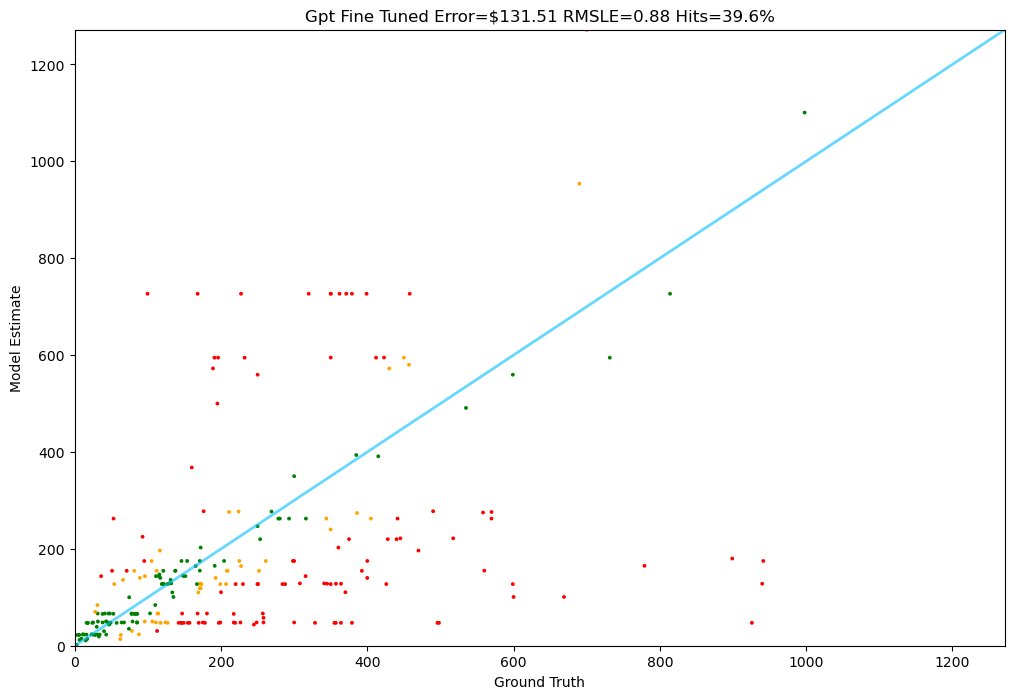

In [45]:
Tester.test(gpt_fine_tuned, test)